In [1]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
df = pd.read_csv("/content/Combined.csv")
print(df.head())
print(df.columns)

                                            Headline  \
0      عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار   
1  US Lawmaker: Ten ISIS Fighters Have Been Appre...   
2  Video shows ISIL beheading of photojournalist ...   
3  اکشے کمار کی فلم پیڈمین 9فروری کو روس میں بھی ...   
4     فیس بک اسٹیٹس بڑے فو نٹ میں لکھنے کا سان طریقہ   

                                         articleBody     Stance sentiment  
0  ممبئی اردو پوائنٹ اخبارتازہ ترین این این ئی05 ...  unrelated  positive  
1  FORT DEVENS, Massachusetts -\n\nInfamous Bosto...  unrelated  negative  
2  KANSAS CITY, Mo. - Kansas City health official...  unrelated   neutral  
3  ممبئی اردو پوائنٹ اخبارتازہ ترین اے پی پی 07 ف...  unrelated  negative  
4  فیس بک میں ایک نئی تبدیلی ئی ہے جس کو تبدیل ہو...  unrelated   neutral  
Index(['Headline', 'articleBody', 'Stance', 'sentiment'], dtype='object')


In [3]:
df = df[['Headline', 'articleBody', 'Stance']]

# Remove dates(digits) also as they does not make effect on stance detection and produce noise
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\u0600-\u06FF\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['Headline'] = df['Headline'].apply(clean_text)
df['articleBody'] = df['articleBody'].apply(clean_text)

print(df.head())

                                            Headline  \
0      عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار   
1  us lawmaker ten isis fighters have been appreh...   
2  video shows isil beheading of photojournalist ...   
3  اکشے کمار کی فلم پیڈمین فروری کو روس میں بھی ر...   
4     فیس بک اسٹیٹس بڑے فو نٹ میں لکھنے کا سان طریقہ   

                                         articleBody     Stance  
0  ممبئی اردو پوائنٹ اخبارتازہ ترین این این ئی ست...  unrelated  
1  fort devens massachusetts infamous boston mara...  unrelated  
2  kansas city mo kansas city health officials sa...  unrelated  
3  ممبئی اردو پوائنٹ اخبارتازہ ترین اے پی پی فرور...  unrelated  
4  فیس بک میں ایک نئی تبدیلی ئی ہے جس کو تبدیل ہو...  unrelated  


In [4]:
df['text'] = df['Headline'] + " " + df['articleBody']

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Stance'])
print(label_encoder.classes_)

print(df.head())

['agree' 'disagree' 'discuss' 'unrelated']
                                            Headline  \
0      عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار   
1  us lawmaker ten isis fighters have been appreh...   
2  video shows isil beheading of photojournalist ...   
3  اکشے کمار کی فلم پیڈمین فروری کو روس میں بھی ر...   
4     فیس بک اسٹیٹس بڑے فو نٹ میں لکھنے کا سان طریقہ   

                                         articleBody     Stance  \
0  ممبئی اردو پوائنٹ اخبارتازہ ترین این این ئی ست...  unrelated   
1  fort devens massachusetts infamous boston mara...  unrelated   
2  kansas city mo kansas city health officials sa...  unrelated   
3  ممبئی اردو پوائنٹ اخبارتازہ ترین اے پی پی فرور...  unrelated   
4  فیس بک میں ایک نئی تبدیلی ئی ہے جس کو تبدیل ہو...  unrelated   

                                                text  label  
0  عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار ...      3  
1  us lawmaker ten isis fighters have been appreh...      3  
2  video shows isil beheading o

In [5]:
# A simple tokenizer that builds a vocabulary and converts words to IDs.

def tokenize(text):
    return text.split()

tokenized_texts = [tokenize(t) for t in df['text']]

# Build vocabulary
all_words = [word for tokens in tokenized_texts for word in tokens]
vocab = Counter(all_words)
vocab = {word: i+2 for i, (word, _) in enumerate(vocab.items())}  # +2 to reserve 0,1 for PAD, OOV
vocab["<PAD>"] = 0
vocab["<OOV>"] = 1

# Convert words to numbers
def text_to_sequence(tokens, vocab):
    return [vocab.get(w, vocab["<OOV>"]) for w in tokens]

encoded_texts = [text_to_sequence(tokens, vocab) for tokens in tokenized_texts]

In [6]:
# Pad sequences to equal length as neural networks need same length inputs
max_len = 200

def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        return seq + [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        return seq[:max_len]

padded_texts = [pad_sequence(seq, max_len) for seq in encoded_texts]

In [7]:
# Split into train, validation and tests sets

X_train, X_temp, y_train, y_temp = train_test_split(
    padded_texts, df['label'],
    test_size=0.30,               # 30% goes to temp (val + test)
    random_state=42,
    stratify=df['label']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,               # half of 30% → 15%
    random_state=42,
    stratify=y_temp
)

print("Train set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

Train set size: 55986
Validation set size: 11997
Test set size: 11997


In [8]:
# For Loading data during training, make a simple class
class StanceDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

train_dataset = StanceDataset(X_train, y_train)
val_dataset = StanceDataset(X_val, y_val)
test_dataset = StanceDataset(X_test, y_test)

In [9]:
# DataLoader for batching
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [10]:
# Using Pre-Trained Embeddings
import numpy as np

# Load GloVe embeddings (make sure glove.6B.100d.txt is downloaded in your path)
embeddings_index = {}
with open("/content/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} word vectors.")

# Build embedding matrix
embedding_dim = 100  # same as GloVe dimension
embedding_matrix = np.zeros((len(vocab), embedding_dim))
for word, idx in vocab.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[idx] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Loaded 400000 word vectors.
Embedding matrix shape: (192473, 100)


In [16]:
# Building the Model
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=1, dropout=0.5):
        super(BiLSTMModel, self).__init__()

        # Pretrained Embedding Layer (GloVe)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Load pretrained weights into the embedding layer
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        # Optionally freeze embeddings so they aren’t trained further
        self.embedding.weight.requires_grad = True

        # BiLSTM: reads both directions
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout)

        # Dropout to reduce overfitting
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer → maps to stance labels
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 because BiLSTM = 2 directions

    def forward(self, x):
        # x shape → [batch_size, seq_len]
        embedded = self.embedding(x)                      # → [batch, seq_len, embed_dim]
        lstm_out, (hidden, cell) = self.lstm(embedded)    # → output from both directions

        # concatenate last forward and backward hidden states
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        dropped = self.dropout(hidden_cat)
        out = self.fc(dropped)

        return out

In [19]:
# Initialize model and hyperparameters
vocab_size = len(vocab)
embed_dim = 100
hidden_dim = 128
output_dim = len(label_encoder.classes_)

model = BiLSTMModel(vocab_size, embed_dim, hidden_dim, output_dim)
print(model)


BiLSTMModel(
  (embedding): Embedding(192473, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


In [20]:
# Set up training tools

if torch.cuda.is_available():
    print("GPU is available")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available — using CPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

No GPU available — using CPU


In [21]:
# Training Logic
# Also store loss and accuracy for each epoch
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

num_epochs = 3  # you can increase later
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # TRAINING
    model.train()                            # set model to training mode
    total_train_loss = 0
    all_preds, all_labels = [], []

    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()                # clear previous gradients
        outputs = model(texts)               # forward pass
        loss = criterion(outputs, labels)    # calculate loss
        loss.backward()                      # compute gradients
        optimizer.step()                     # update weights

        total_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(all_labels, all_preds)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # VALIDATION
    model.eval()
    total_val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/3 | Train Loss: 0.8339, Train Acc: 0.6926 | Val Loss: 0.7568, Val Acc: 0.7267
Epoch 2/3 | Train Loss: 0.6504, Train Acc: 0.7533 | Val Loss: 0.6936, Val Acc: 0.7464
Epoch 3/3 | Train Loss: 0.4762, Train Acc: 0.8225 | Val Loss: 0.7329, Val Acc: 0.7469


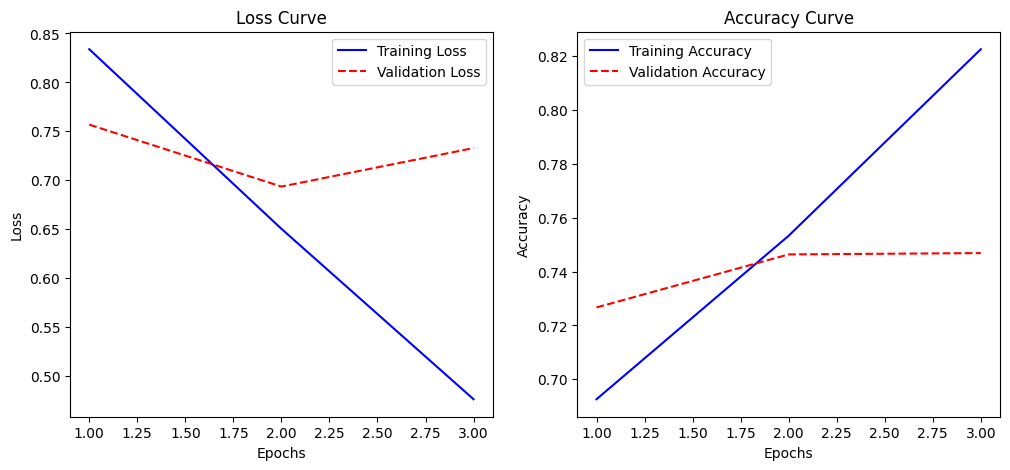

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs+1)

plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Training Loss')
plt.plot(epochs, val_losses, 'r--', label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'r--', label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Classification Report:
              precision    recall  f1-score   support

       agree       0.46      0.34      0.39      1710
    disagree       0.46      0.10      0.17       303
     discuss       0.70      0.57      0.63      1870
   unrelated       0.80      0.90      0.85      8114

    accuracy                           0.75     11997
   macro avg       0.60      0.48      0.51     11997
weighted avg       0.73      0.75      0.73     11997



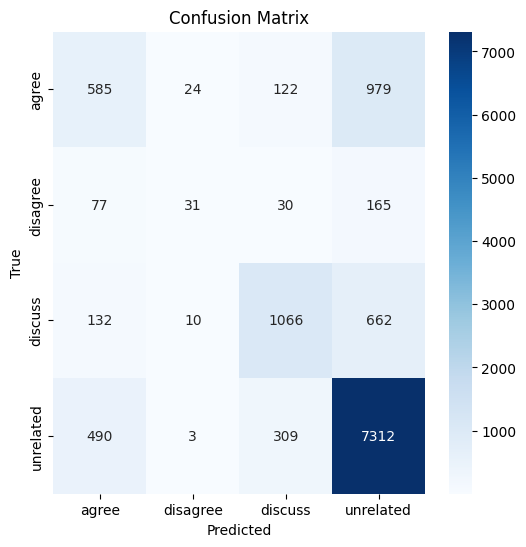

In [23]:
# Precision, Recall, F1-score, and Confusion Matrix

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Evaluate on test data
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for texts, labels in test_loader:
        texts, labels = texts.to(device), labels.to(device)
        outputs = model(texts)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Exact Match (EM) = how often the model predicts exactly the right class (same as accuracy in this case)

em_score = accuracy_score(test_labels, test_preds)
print(f"Exact Match (EM) Score: {em_score:.4f}")

Exact Match (EM) Score: 0.7497


In [25]:
# Save model, tokenizer, and label encoder
import torch
import pickle

# 1. Save model weights
torch.save(model.state_dict(), "bilstm_stance_model.pth")

# 2. Save tokenizer (vocab)
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(vocab, f)

# 3. Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Model, tokenizer, and label encoder saved successfully!")

Model, tokenizer, and label encoder saved successfully!


In [26]:
# Load tokenizer and label encoder

with open("tokenizer.pkl", "rb") as f:
    vocab = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# Rebuild the model structure
vocab_size = len(vocab)
model = BiLSTMModel(vocab_size, 100, 128, len(label_encoder.classes_))
model.load_state_dict(torch.load("bilstm_stance_model.pth"))
model.eval()
print("Model loaded and ready for inference!")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Model loaded and ready for inference!


In [38]:
# Make predictions on new text
import torch.nn.functional as F

def predict_stance(headline, article, model, vocab, label_encoder, max_len=200):
    model.eval()
    with torch.no_grad():
        # Simple tokenization (same as before)
        tokens = (headline + " " + article).lower().split()
        seq = [vocab.get(token, vocab["<OOV>"]) for token in tokens]

        # Pad/truncate
        if len(seq) < max_len:
            seq += [vocab["<PAD>"]] * (max_len - len(seq))
        else:
            seq = seq[:max_len]

        # Convert to tensor
        input_tensor = torch.tensor([seq])

        # Predict
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        stance = label_encoder.classes_[pred_idx]

        return stance, probs[0][pred_idx].item()


In [41]:
# Example
headline = "ISIS: Desperate mum told 'you've just eaten your son' after visiting militants' base in search of kidnap victim"

article = """Islamic State fighters fed the mum cooked meat and rice before telling her it was the remains of her kidnapped son, a British dad who went to fight IS has revealed

Sick ISIS militants fed a desperate mum the mutilated remains of her son - after telling her it was cooked meat and rice, it was claimed today.

The son had been captured and taken prisoner by Islamic State militants in Mosul, Iraq.

The worried mum then bravely visited the terror group's headquarters in a bid to speak to her loved one.

ISIS fighters told the mum she should eat before seeing her son because she had travelled a long way.

However, after giving the mother cooked meat, rice and soup, she was horrified to be told she had just eaten her son.

British dad Yasir Abdulla, who left his home in Keighley, West Yorkshire to fight against ISIS, said he joined the battle against the terror group after being told this story.

Ben Lack   Inspired: Yasir Abdulla went to fight ISIS after hearing this story

He said: "The ISIS men told her to sit down because she had travelled a long way and said she should have some food before they took her to meet her son.

"But they had killed him and chopped him up and after she finished the meal and asked to see her son they laughed and said, 'You've just eaten him'."

And after witnessing the horrors of the terror group up close, Yasir says they have 'hijacked Islam'.

"ISIS are wrong. They behead, burn and get those they are against do dig their own graves before they execute them," he said.

"Nobody wants to get captured by ISIS, that would be the worst thing. If I was defending I would fight to my last bullet and use that on myself."

Yasir is aware of Brits joining ISIS but has not encountered any in battle. "I have seen what Jihad John has done and I think that person needs to be captured and executed," he said.

VIEW GALLERY

"England is a lovely place, the people are lovely and the Government is good. Whatever the British joining ISIS say is wrong about Britain, they just hate.

"They are not Muslims, they have hijacked Islam. Muslim people should not cut the head off an animal in front of another animal, but these ISIS behead people every day in front of other people."

The incident is the latest atrocity from the terror group.

It emerged this weekend that Islamic State militants blindfolded a 'gay' man, threw him from a roof then stoned his corpse in Syria.

Horrific images revealed by ISIS show the barbaric killing in front of a baying crowd carried out at a building in Raqqa.

It is believed the man was sentenced to death by a sharia court.

The man was described as being a 'child of Lot' and accused of committing acts of sodomy, according to the Daily Mail.

'Lot' is a reference to a prophet of God whose story in the Qu'ran is used to demonstrate Islam's supposed disapproval of rape and homosexuality.

#ISIS stoned a man to death in Tal Abiad in #Raqqa for being homosexual after throwing him from the roof of the Islamic Court building.— الرقة تذبح بصمت (@Raqqa_Sl) February 27, 2015

The images appear to show the man was blindfolded and had his feet tied before being hurled onto rubble from a tall building.

Crowds then gather round and pelt the corpse with rocks.

It was the fourth time in a few weeks that the jihadist group has used the brutal execution method for alleged homosexuality .

After claiming they found videos on his mobile phone showing him 'practising indecent acts with males,' a 20-year old man was stoned to death in the Syrian province of Deir Ezzor in late November, according to the Syrian Observatory for Human Rights.

Video loading"""

pred, confidence = predict_stance(headline, article, model, vocab, label_encoder)
print(f"Predicted stance: {pred} (confidence: {confidence:.2f})")

Predicted stance: discuss (confidence: 0.83)
